In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/siddharth0231/ipl-2022-dataset/IPL.csv


In [2]:
import seaborn as sns
import matplotlib.pyplot as mp
import warnings
warnings.filterwarnings("ignore")

In [3]:
data = pd.read_csv("/kaggle/input/datasets/siddharth0231/ipl-2022-dataset/IPL.csv")
data.head

<bound method NDFrame.head of     match_id           date                                         venue  \
0          1  March 26,2022                      Wankhede Stadium, Mumbai   
1          2  March 27,2022                     Brabourne Stadium, Mumbai   
2          3  March 27,2022            Dr DY Patil Sports Academy, Mumbai   
3          4  March 28,2022                      Wankhede Stadium, Mumbai   
4          5  March 29,2022  Maharashtra Cricket Association Stadium,Pune   
..       ...            ...                                           ...   
69        70    May 22,2022                      Wankhede Stadium, Mumbai   
70        71    May 24,2022                         Eden Gardens, Kolkata   
71        72    May 25,2022                         Eden Gardens, Kolkata   
72        73    May 27,2022              Narendra Modi Stadium, Ahmedabad   
73        74    May 29,2022              Narendra Modi Stadium, Ahmedabad   

        team1      team2    stage toss_winner

In [4]:
data

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,second_ings_score,second_ings_wkts,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure
0,1,"March 26,2022","Wankhede Stadium, Mumbai",Chennai,Kolkata,Group,Kolkata,Field,131,5,133,4,Kolkata,Wickets,6,Umesh Yadav,MS Dhoni,50,Dwayne Bravo,3--20
1,2,"March 27,2022","Brabourne Stadium, Mumbai",Delhi,Mumbai,Group,Delhi,Field,177,5,179,6,Delhi,Wickets,4,Kuldeep Yadav,Ishan Kishan,81,Kuldeep Yadav,3--18
2,3,"March 27,2022","Dr DY Patil Sports Academy, Mumbai",Banglore,Punjab,Group,Punjab,Field,205,2,208,5,Punjab,Wickets,5,Odean Smith,Faf du Plessis,88,Mohammed Siraj,2--59
3,4,"March 28,2022","Wankhede Stadium, Mumbai",Gujarat,Lucknow,Group,Gujarat,Field,158,6,161,5,Gujarat,Wickets,5,Mohammed Shami,Deepak Hooda,55,Mohammed Shami,3--25
4,5,"March 29,2022","Maharashtra Cricket Association Stadium,Pune",Hyderabad,Rajasthan,Group,Hyderabad,Field,210,6,149,7,Rajasthan,Runs,61,Sanju Samson,Aiden Markram,57,Yuzvendra Chahal,3--22
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69,70,"May 22,2022","Wankhede Stadium, Mumbai",Hyderabad,Punjab,Group,Hyderabad,Bat,157,8,160,5,Punjab,Wickets,5,Harpreet Brar,Liam Livingstone,49,Harpreet Brar,3--26
70,71,"May 24,2022","Eden Gardens, Kolkata",Gujarat,Rajasthan,Playoff,Gujarat,Field,188,6,191,3,Gujarat,Wickets,7,David Miller,Jos Buttler,89,Hardik Pandya,1--14
71,72,"May 25,2022","Eden Gardens, Kolkata",Banglore,Lucknow,Playoff,Lucknow,Field,207,4,193,6,Banglore,Runs,14,Rajat Patidar,Rajat Patidar,112,Josh Hazlewood,3--43
72,73,"May 27,2022","Narendra Modi Stadium, Ahmedabad",Banglore,Rajasthan,Playoff,Rajasthan,Field,157,8,161,3,Rajasthan,Wickets,7,Jos Buttler,Jos Buttler,106,Prasidh Krishna,3--22


**Data Size**

In [5]:
print("Size " , data.size)
print("No. of row" , data.shape[0])
print("No. of colum", data.shape[1])

Size  1480
No. of row 74
No. of colum 20


Null Value

In [6]:
data.isnull().sum()

match_id               0
date                   0
venue                  0
team1                  0
team2                  0
stage                  0
toss_winner            0
toss_decision          0
first_ings_score       0
first_ings_wkts        0
second_ings_score      0
second_ings_wkts       0
match_winner           0
won_by                 0
margin                 0
player_of_the_match    0
top_scorer             0
highscore              0
best_bowling           0
best_bowling_figure    0
dtype: int64

# Most Match win

Text(0.5, 1.0, 'Most Match Wins')

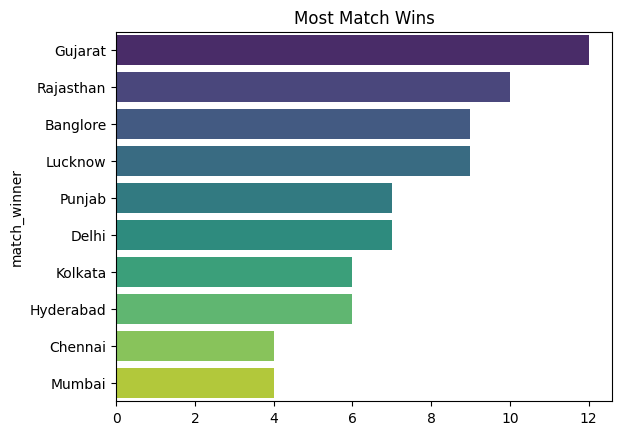

In [7]:
win = data["match_winner"].value_counts()
sns.barplot(y = win.index , x = win.values , palette = "viridis")
mp.title("Most Match Wins")

# Toss Decision  

<Axes: xlabel='toss_decision', ylabel='count'>

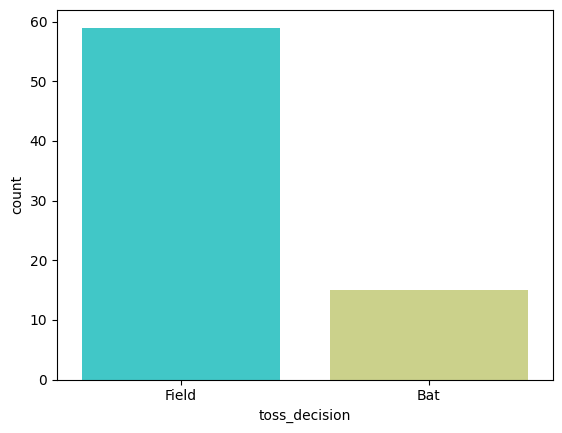

In [8]:
sns.countplot(x = data["toss_decision"], palette = "rainbow")


# Best player in every match

<Axes: xlabel='player_of_the_match', ylabel='count'>

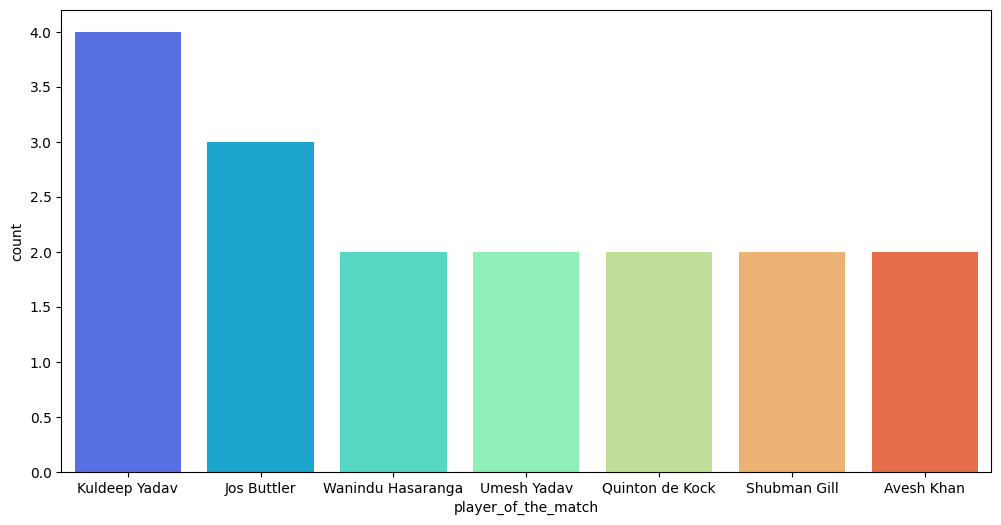

In [9]:
count = data["player_of_the_match"].value_counts().head(7)
mp.figure(figsize=(12,6))
sns.barplot(count , palette = "rainbow")

# Plot the number of matches played at each venue (bar plot).



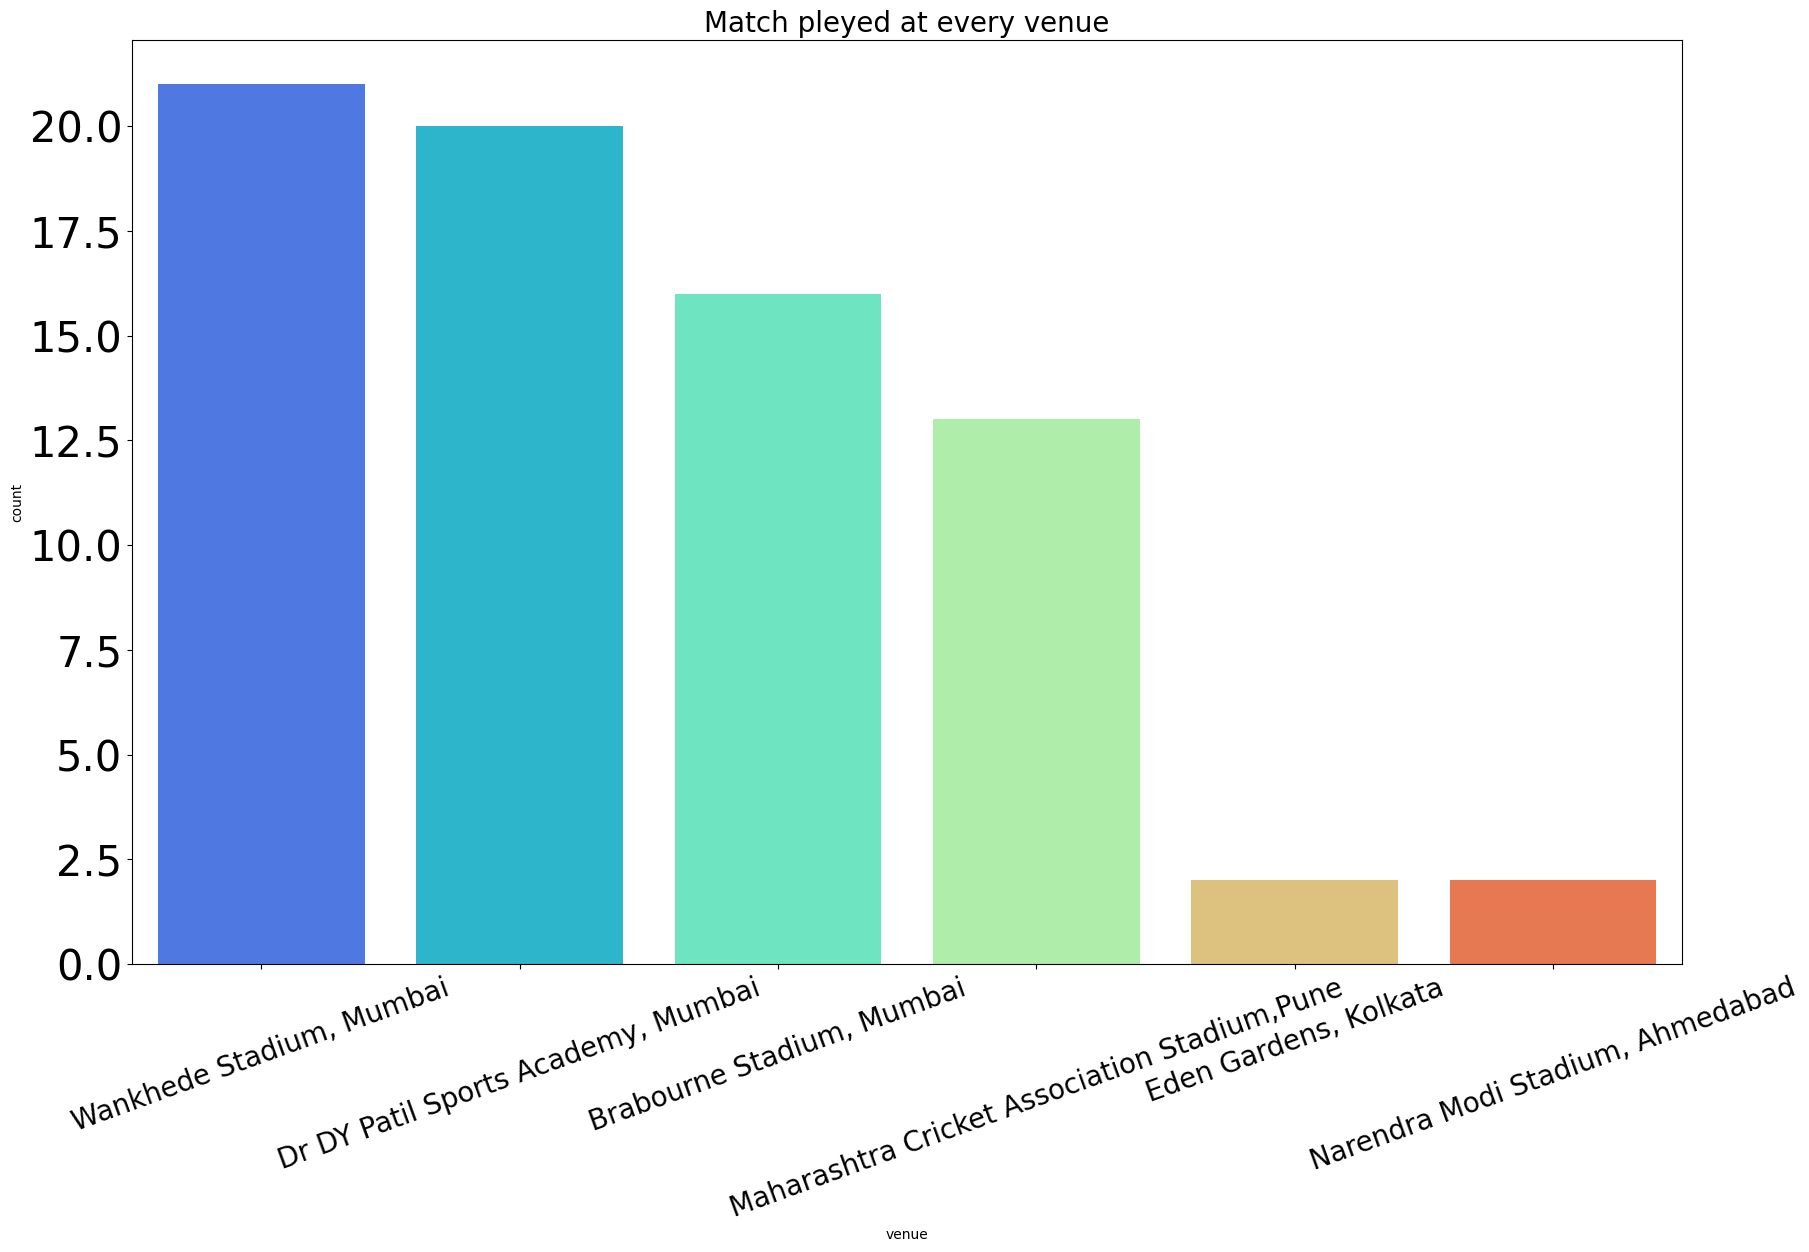

In [10]:
match = data["venue"].value_counts()
mp.figure(figsize=(20,12))
sns.barplot(match , palette = "rainbow")
mp.xticks(rotation=20, fontsize=20)
mp.yticks(fontsize = 30)
mp.title("Match pleyed at every venue" , fontsize = 20);

# Show the distribution of toss decisions (bat vs field) (pie chart)

''

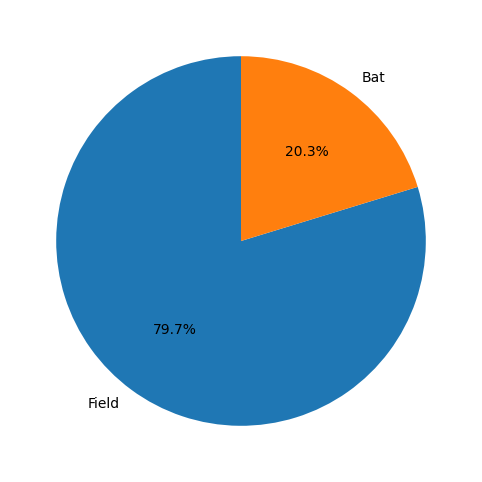

In [11]:
bvt = data['toss_decision'].value_counts()
mp.figure(figsize = (12,6))
mp.pie(bvt,labels=bvt.index,autopct='%1.1f%%',startangle=90)

;

# Compare matches won by each team (count plot).

''

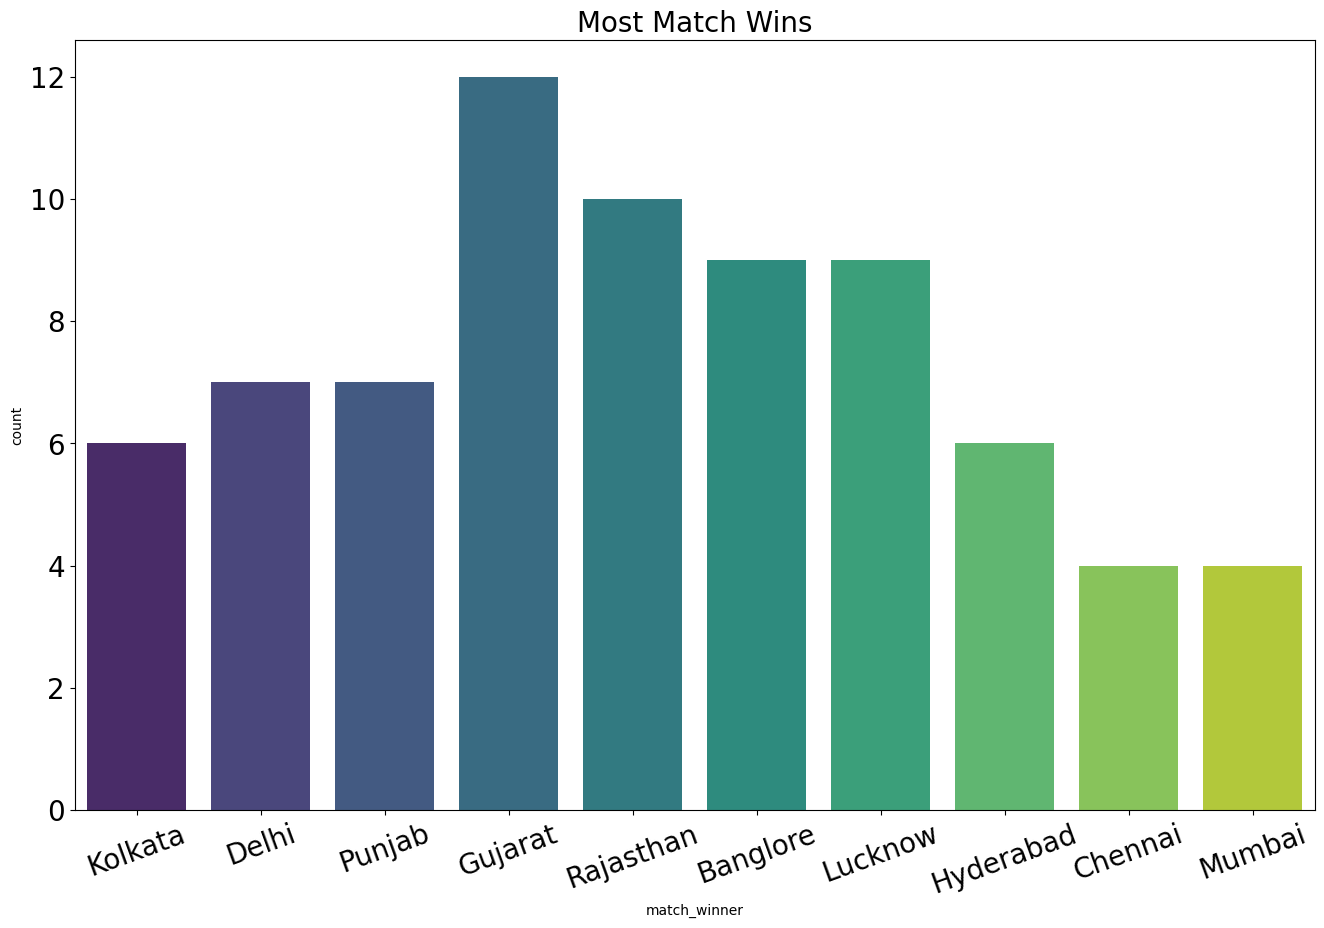

In [12]:
win = data["match_winner"]
mp.figure(figsize = (16,10))
sns.countplot(x = win, palette = "viridis")
mp.title("Most Match Wins" , fontsize = 20)
mp.yticks(fontsize = 20)
mp.xticks(rotation = 20 , fontsize = 20)
;

# Plot the top 10 players of the match winners (bar plot)

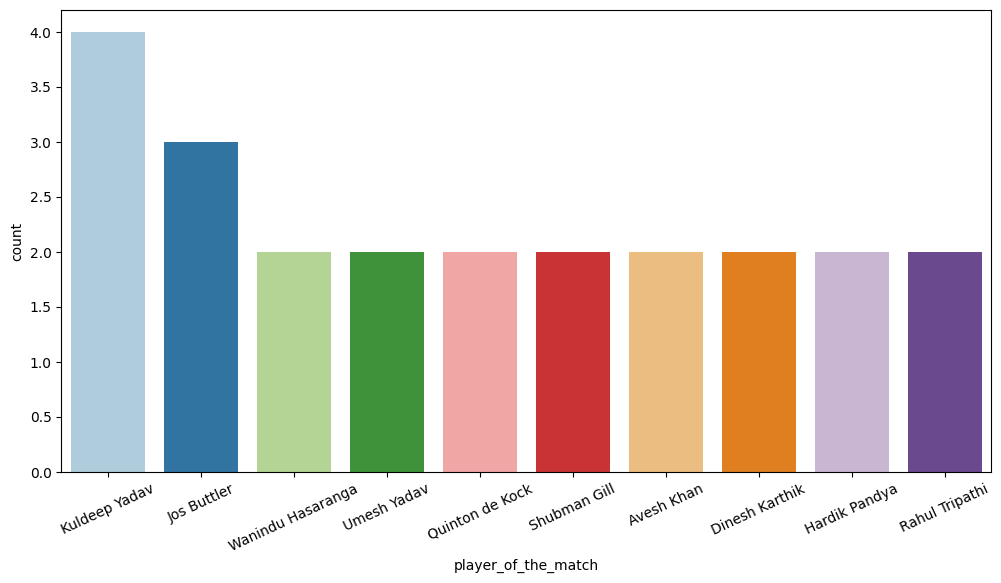

In [13]:
player = data["player_of_the_match"].value_counts().head(10)
mp.figure(figsize = (12,6))
sns.barplot(player , palette = "Paired")
mp.xticks(rotation = 25);

# Visualize the distribution of first innings scores (histogram).

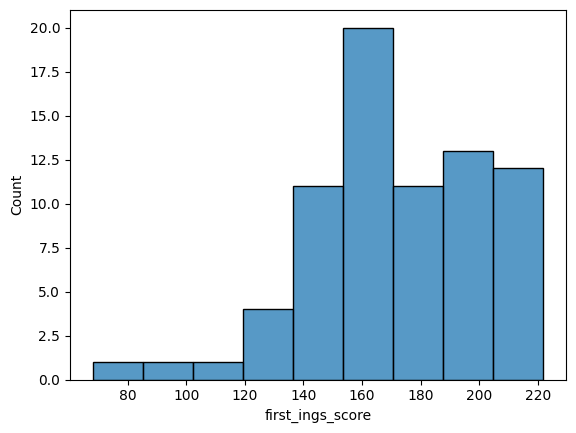

In [14]:
first_inning = data["first_ings_score"]
sns.histplot(first_inning , palette = "Paired");

# Compare average first innings scores per team (bar plot).



In [15]:
first_innings_avg = data["first_ings_score"]

# Show the relationship between first innings score and second innings score (scatter plot).



# Plot the distribution of victory margins (histogram).



# Compare win margins grouped by won_by (Runs vs Wickets) (box plot).



# Show the trend of matches per stage (Group, Playoff, Final) (count plot).



# Plot the top scorers with their high scores (horizontal bar plot).



# Visualize the best bowling figures distribution (bar plot).



# Create a heatmap of correlation between numerical columns (first_ings_score, second_ings_score, margin).



# Compare toss winners vs match winners (stacked bar chart).



# Plot the number of matches won by margin type (Runs vs Wickets) (count plot).



# Show the average margin of victory per team (bar plot).



# Plot the distribution of wickets lost in first innings (histogram).



# Compare venues by average first innings score (bar plot).



# Plot the number of times each player was top scorer (bar plot).



# Create a line plot showing toss decision trends over time (date column).